# Lecture 11c — Multiple linear regression (scikit-learn)

`lec_11a` fit one feature with three libraries and ended with a *"from here on, **scikit-learn only**"* note.  
This notebook lives up to that. Every fit, every split, every diagnostic uses sklearn.  
Where sklearn does not provide the diagnostic out of the box (residual QQ plots, manual VIF in `lec_11f`), we reach for `scipy.stats` or `numpy` — never back to statsmodels.

## Three industry uses for multiple linear regression with a continuous target

1. **Predicting university grades from prior academic performance** — exactly the dataset in this notebook. Admissions analytics teams build models of this shape from high-school records to predict first-year performance.
2. **Predicting employee salary from experience, education, role, and location.** Standard HR analytics; the conditional interpretation of each coefficient is the entire job.
3. **Predicting customer lifetime value (CLV)** from acquisition channel, first-month behaviour, and demographics. A foundational regression in marketing analytics — often the baseline before more flexible models are tried.

## What this notebook covers

- Load the `grades_factors.xlsx` dataset (n = 80, six features predicting university calculus grade).
- Encode the categorical and check feature-feature correlations.
- An **aside on the intercept** — when (almost never) it is OK to drop it.
- Fit multiple regression with `sklearn.linear_model.LinearRegression`.
- **Choose features scientifically** — read the statsmodels OLS summary (R²-adj, F-statistic, p-values, AIC), iterate subsets, then verify with sklearn-native selectors (`SequentialFeatureSelector`, `RFE`).
- A **train/test split** (70 / 30) and a **train-vs-test R²** feature-count sweep that *reads as a diagnostic*, not a model-selection mechanic.
- Residual diagnostics live in **`lec_11b` (Assumptions)** — refer there to verify the OLS assumptions hold before relying on this fit.


## A. Setup and load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

In [2]:
# Relative path: this notebook lives next to grades_factors.xlsx.
df = pd.read_excel("grades_factors.xlsx")
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head()

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_code,gender,calc
0,0,27,21,3.5,68,0,F,62
1,0,29,16,4.0,99,0,F,75
2,1,30,22,4.0,98,1,M,95
3,0,34,25,3.0,90,1,M,78
4,0,29,22,4.0,99,0,F,95


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   calc_hs      80 non-null     int64  
 1   act_math     80 non-null     int64  
 2   alg_place    80 non-null     int64  
 3   alg2_grade   80 non-null     float64
 4   hs_rank      80 non-null     int64  
 5   gender_code  80 non-null     int64  
 6   gender       80 non-null     object 
 7   calc         80 non-null     int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 5.1+ KB


In [4]:
df.describe().round(2)

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_code,calc
count,80.00,80.00,80.00,80.00,80.00,80.00,80.00
mean,0.25,28.25,19.42,3.61,87.68,0.54,80.15
std,0.44,3.25,4.71,0.56,12.18,0.50,11.44
min,0.00,16.00,10.00,2.00,46.00,0.00,49.00
25%,0.00,27.00,15.75,3.00,82.00,0.00,72.00
50%,0.00,28.00,19.00,4.00,92.00,1.00,80.50
75%,0.25,30.00,23.00,4.00,97.00,1.00,89.25
max,1.00,35.00,30.00,4.00,99.00,1.00,99.00


## B. The categorical feature

`gender_code` is already a binary 0/1 column (0 = F, 1 = M) — it can drop straight into a regression as a feature. We rename it to `gender_male` for readability and drop the redundant string column `gender`.

In [5]:
df_encoded = df.drop(columns=["gender"]).rename(columns={"gender_code": "gender_male"})
df_encoded.head()

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_male,calc
0,0,27,21,3.5,68,0,62
1,0,29,16,4.0,99,0,75
2,1,30,22,4.0,98,1,95
3,0,34,25,3.0,90,1,78
4,0,29,22,4.0,99,0,95


## C. Correlation check before fitting

Look at correlations between features and target. High feature-feature correlation will haunt your coefficient interpretation — see `lec_11d` for the pitfalls.

In [6]:
feature_cols = ["calc_hs", "act_math", "alg_place", "alg2_grade", "hs_rank", "gender_male"]
target_col = "calc"

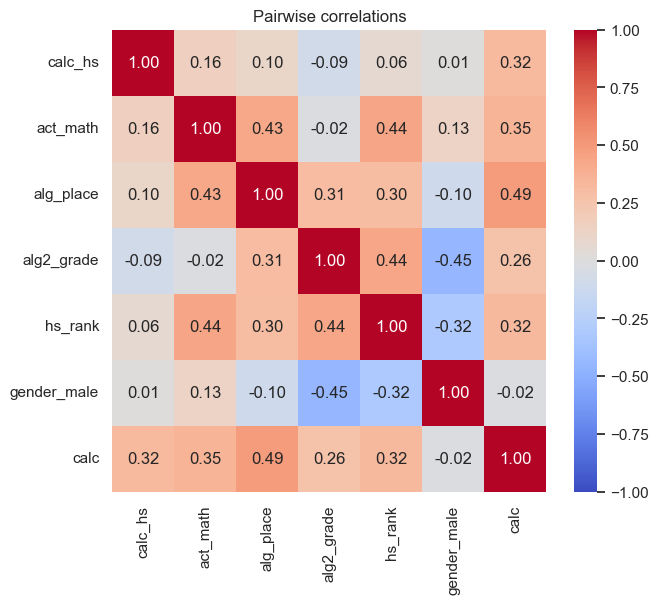

In [7]:
correlations = df_encoded[feature_cols + [target_col]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pairwise correlations")
plt.show()

The math-ability proxies (`calc_hs`, `act_math`, `alg2_grade`) correlate with each other and with the target. The pitfalls of reading partial coefficients on overlapping features are `lec_11d`'s topic; we use the result here to motivate the train/test discipline in §F and the intercept aside in §C2.

> ⏱ **Skip if running long.** §C2 below is an *aside* on why we keep the intercept (with the no-intercept bias + R² gotcha). Self-contained — students can read it after class. The main fitting workflow in §D does not depend on it.

## C2. Aside — why we keep the intercept (and why you almost never drop it)

`sklearn.linear_model.LinearRegression` defaults to `fit_intercept=True` and adds the intercept term automatically.  
A common beginner temptation is to *remove* it (`LinearRegression(fit_intercept=False)`, or `sm.OLS(y, X).fit()` without `add_constant`) on the grounds that **"y must be zero when all features are zero"**.  
Almost every time that argument shows up, it is wrong.  
Three reasons to keep the intercept in:

### 1. Biased coefficient estimates

- Without an intercept the model has no "free" constant to absorb the average of `y`.
- The bias that the intercept used to carry gets pushed into the **slope** coefficients.
- The slopes then no longer answer the clean question *"how does y change per unit X, holding the rest constant?"* — they answer that plus an extra term carrying the omitted constant.
- On any dataset whose target is not centred near zero (most real data), the slope numbers change materially when the intercept is dropped, even though the underlying X–y relationship has not moved.

### 2. The R² number changes character — and can lie

The story differs between libraries; the gotcha is worth knowing in both:

- **scikit-learn** (`LinearRegression(fit_intercept=False).score(...)`) keeps using the **centred** R² formula:  
  `1 − SSE / SST_centred`, where `SST_centred = sum((y − y.mean())²)`.  
  When the no-intercept fit predicts worse than the constant model `ŷ = y.mean()`, sklearn's R² goes **negative** — an honest red flag.
- **statsmodels** silently switches to the **uncentred** formula:  
  `1 − SSE / SST_uncentred`, where `SST_uncentred = sum(y²)`.  
  On data with a non-zero target mean (most real data) this number **inflates dramatically** — you can see *"R² = 0.99"* on a model that is in fact worse at prediction than the with-intercept fit.  
  The number labelled R² in a no-intercept statsmodels summary is **not** the same thing as the R² you read on every other regression.

### 3. Worse extrapolation, no real gain

- Forcing the line through the origin anchors the fit to a region of feature space your data probably doesn't cover.
- The slope has to bend back unnaturally to pass through the actual data, and predictions at the edges of your feature range get worse.
- You pay this cost to satisfy a constraint the data did not ask for.

### When is it acceptable to drop the intercept?

Only when there is a **physical** reason for `y = 0` at `X = 0` — e.g. `force = mass × acceleration` (zero mass really does imply zero force), or a quantity that is structurally proportional.
Even then, the safe workflow is:

1. Fit with intercept.
2. Check whether the intercept is distinguishable from zero.
3. Only drop it if the test fails.

Forcing it from the start is a strong constraint that the data may not support.

### See it on the data

We fit the same OLS twice with sklearn — once with the default `fit_intercept=True`, once with `fit_intercept=False` — and put the two coefficient tables side by side.

In [8]:
X_demo = df_encoded[feature_cols].astype(float)
y_demo = df_encoded[target_col].astype(float)

with_intercept    = LinearRegression(fit_intercept=True ).fit(X_demo, y_demo)
without_intercept = LinearRegression(fit_intercept=False).fit(X_demo, y_demo)

comparison = pd.DataFrame({
    "with_intercept":    with_intercept.coef_,
    "without_intercept": without_intercept.coef_,
}, index=feature_cols).round(3)
comparison["abs_change"] = (comparison["without_intercept"]
                            - comparison["with_intercept"]).abs().round(3)
comparison

,with_intercept,without_intercept,abs_change
calc_hs,7.192,7.206,0.014
act_math,0.352,0.887,0.535
alg_place,0.827,0.729,0.098
alg2_grade,3.683,6.760,3.077
hs_rank,0.111,0.139,0.028
gender_male,2.627,4.272,1.645


Read the `abs_change` column.  
The slope estimates *move* — sometimes by a substantial fraction of their original magnitude — purely because we removed the intercept.  
Nothing about the data changed; the model just lost the constant it could use to absorb the mean.  
The *"without intercept"* coefficients are not the right answer; they are answers to a different (and worse-posed) question.

Now the R²:


In [9]:
print(f"sklearn R^2 with intercept:    {with_intercept.score(X_demo, y_demo):+.3f}  (centred)")
print(f"sklearn R^2 without intercept: {without_intercept.score(X_demo, y_demo):+.3f}  (still centred -- can go negative)")
print(f"Mean of y: {y_demo.mean():.1f}")

sklearn R^2 with intercept:    +0.372  (centred)
sklearn R^2 without intercept: +0.328  (still centred -- can go negative)
Mean of y: 80.2


sklearn's R² stays on the **centred** scale even when you remove the intercept.
The number can therefore go **negative** when the no-intercept fit is worse than the constant baseline `ŷ = y.mean()` — an honest signal that removing the intercept made the fit worse.

If you used **statsmodels** instead, you would see the *opposite*: the no-intercept R² would **inflate** (statsmodels switches to an uncentred formula), giving a misleadingly high number. Both behaviours are documented; both mislead students who don't realise the formula changed.

**References:**

- ["When is it ok to remove the intercept in a linear regression model?"](https://stats.stackexchange.com/questions/7948/when-is-it-ok-to-remove-the-intercept-in-a-linear-regression-model) — the canonical Cross Validated thread.
- ["Removal of statistically significant intercept term increases R² in linear model"](https://stats.stackexchange.com/questions/26176/removal-of-statistically-significant-intercept-term-increases-r2-in-linear-mode) — the statsmodels-specific R² inflation, unpacked.
- ["In the LinearRegression method in sklearn, what exactly is the fit_intercept parameter doing?"](https://stackoverflow.com/questions/46779605/sklearn-linearregression-fit-intercept-false-vs-fit-intercept-true) — the sklearn mechanics, including how `fit_intercept=False` interacts with feature scaling.

**Rule of thumb for this course:** always fit with an intercept.
If you ever feel the urge to remove it, write down your reason. If the reason is anything other than "physics says `y = 0` at `X = 0`", keep the intercept.


## D. Multiple regression with `LinearRegression`

`sklearn.linear_model.LinearRegression` is the sklearn-ecosystem equivalent of the `sm.OLS` you met in `lec_11a`.

- Same closed-form OLS solution under the hood.
- Same `.fit(X, y)` / `.predict(X)` / `.score(X, y)` interface as every other sklearn estimator.
- That uniformity is what makes the pipelines in `lec_11e` and the cross-validation in Lecture 13 possible.

sklearn deliberately does **not** print standard errors, p-values, F-statistics, or AIC.  
For the *prediction* workflow (train/test, overfitting curve, regularisation) those numbers are not needed.  
For the *feature-selection* step that comes next, they are — so **§E refits this same model with statsmodels** to get them, then shows the sklearn-native feature selectors that do the same job model-agnostically.

In [10]:
X = df_encoded[feature_cols].astype(float)
y = df_encoded[target_col].astype(float)


In [11]:

ols_full = LinearRegression().fit(X, y)


In [12]:

print(f"Intercept: {ols_full.intercept_:+.3f}")
print()
print("Coefficients (per 1-unit change in each feature, holding the rest constant):")
for name, coef in zip(feature_cols, ols_full.coef_):
    print(f"  {name:<14}  {coef:+.3f}")
print()
print(f"Training R^2: {ols_full.score(X, y):.3f}")

Intercept: +27.943

Coefficients (per 1-unit change in each feature, holding the rest constant):
  calc_hs         +7.192
  act_math        +0.352
  alg_place       +0.827
  alg2_grade      +3.683
  hs_rank         +0.111
  gender_male     +2.627

Training R^2: 0.372


### How to read sklearn's output

The four numbers above are everything you can extract from a `LinearRegression` fit:

- **`intercept_`** — the predicted value of `y` when every feature is zero. On this dataset that point is outside the observed range (no student has zero ACT score), but the constant still has to exist for the slopes to be meaningfully interpretable — see §C2.
- **`coef_`** — one slope per feature; *partial* effect of that feature holding the others fixed. On overlapping features (`calc_hs`, `act_math`, `alg2_grade` all measure math ability) the partial-effect framing is treacherous; `lec_11d` unpacks the pitfalls.
- **`score(X, y)`** — the in-sample R²; how well the line passes through the training points. Always an *optimistic* number; the §G test R² below is the honest one.

Can you tell *which* of the six features above are actually pulling their weight? Not from this output — `LinearRegression` returns no p-values, no F-statistic, no AIC.
**§E** brings those numbers in via statsmodels and then shows the sklearn-native selectors that automate the same job.

## E. Choosing features scientifically

Section D fitted all six features and reported coefficients and an in-sample R².
It did **not** tell us *which* of those six features are actually carrying the model — and on overlapping math-ability proxies (`calc_hs`, `act_math`, `alg2_grade`) that is the question that matters.

Two complementary toolsets answer it:

1. **statsmodels' OLS summary table** — the *inferential* view. For every coefficient: a standard error, a t-stat, a p-value, a confidence interval. For the model as a whole: F-statistic, adjusted R², AIC, BIC. The way econometrics has selected features for a century.
2. **sklearn's `feature_selection` module** — the *predictive* view. Wraps any estimator and scores subsets by cross-validated predictive performance (`SequentialFeatureSelector`) or by coefficient magnitude (`RFE`). Model-agnostic; same API for logistic regression, random forests, gradient boosting.

Both views matter. We will use both on the same six features, compare what they pick, and discuss when each is the right tool.

### E1. Refit with statsmodels and read the OLS summary table

The fit itself is identical to §D — statsmodels and sklearn both solve the same closed-form OLS — but `statsmodels.OLS` builds a full inferential summary on top of the fit. We add an explicit constant column because statsmodels (unlike `LinearRegression`) does not insert one automatically.

In [13]:
import statsmodels.api as sm

X_full_sm = sm.add_constant(X)         # adds a column of ones for the intercept
ols_full_sm = sm.OLS(y, X_full_sm).fit()
print(ols_full_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                   calc   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     7.197
Date:                Sat, 23 May 2026   Prob (F-statistic):           4.70e-06
Time:                        14:53:45   Log-Likelihood:                -289.37
No. Observations:                  80   AIC:                             592.7
Df Residuals:                      73   BIC:                             609.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          27.9434     12.438      2.247      

**How to read this table** — five numbers do most of the work:

| Number | What it answers |
|---|---|
| **`R-squared`** | Fraction of variance explained — same as `LinearRegression.score(X, y)`. |
| **`Adj. R-squared`** | Same, but penalised for the number of features. *This* is the one to compare across subsets — plain R² always rises as you add features even if they are noise. |
| **`F-statistic` + `Prob (F-statistic)`** | Is the model as a whole better than predicting `y.mean()`? A tiny `Prob (F)` (here ≈ 5e-06) says yes. |
| **`P>|t|`** per coefficient | Is *this single coefficient* distinguishable from zero, given the other features? Three features here (`act_math`, `hs_rank`, `gender_male`) have p > 0.10 — candidates for removal. |
| **`AIC` / `BIC`** | Information criteria for comparing non-nested models — lower is better. We will watch these as we shrink the feature set. |

Three features have p-values above 0.10: `act_math` (0.42), `hs_rank` (0.34), `gender_male` (0.29). The *inferential* recommendation is: try dropping them and see whether the adjusted R² and AIC actually improve.


In [14]:
def ols_report(features):
    """Fit OLS on `features` (plus intercept) and return a one-row summary."""
    res = sm.OLS(y, sm.add_constant(X[features])).fit()
    return {
        "k_features": len(features),
        "features":   ", ".join(features),
        "R2_adj":     round(res.rsquared_adj, 3),
        "F":          round(res.fvalue, 2),
        "AIC":        round(res.aic, 1),
        "BIC":        round(res.bic, 1),
        "max_p":      round(res.pvalues.drop("const").max(), 3),
    }

# Sanity check on the full model — should match the summary table above.
pd.DataFrame([ols_report(feature_cols)])


,k_features,features,R2_adj,F,AIC,BIC,max_p
0,6,"calc_hs, act_math, alg_place, alg2_grade, hs_r...",0.32,7.2,592.7,609.4,0.417


### E2. Iterate subsets and watch the metrics

The classical inferential recipe is **backward elimination**: at each step, drop the feature with the highest p-value, refit, and watch what happens to adjusted R², F, and AIC. The model gets simpler; sometimes it gets *better*.

Each row below is one round of elimination, dropping the worst-p feature from the previous row.

In [15]:
subsets = [
    ["calc_hs", "act_math", "alg_place", "alg2_grade", "hs_rank", "gender_male"],  # all six
    ["calc_hs", "alg_place", "alg2_grade", "hs_rank", "gender_male"],              # drop act_math (highest p)
    ["calc_hs", "alg_place", "alg2_grade", "hs_rank"],                             # drop gender_male
    ["calc_hs", "alg_place", "hs_rank"],                                           # drop alg2_grade
    ["calc_hs", "alg_place"],                                                      # drop hs_rank — all remaining p < 0.05
]

pd.DataFrame([ols_report(s) for s in subsets])


,k_features,features,R2_adj,F,AIC,BIC,max_p
0,6,"calc_hs, act_math, alg_place, alg2_grade, hs_r...",0.320,7.20,592.7,609.4,0.417
1,5,"calc_hs, alg_place, alg2_grade, hs_rank, gende...",0.323,8.54,591.5,605.8,0.198
2,4,"calc_hs, alg_place, alg2_grade, hs_rank",0.317,10.16,591.3,603.2,0.355
3,3,"calc_hs, alg_place, hs_rank",0.318,13.28,590.2,599.7,0.064
4,2,"calc_hs, alg_place",0.296,17.57,591.8,599.0,0.006


**Two things to read off this table.**

1. **Adjusted R² rises as we drop features, then falls.** The naive R² always shrinks when you remove a feature; the *adjusted* R² only shrinks when the removed feature was carrying its weight. Here it climbs from 0.320 (six features) to 0.323 (five) and stays in that band before dropping at the two-feature model. That tells us the extra features were paying for themselves only marginally.
2. **AIC bottoms out at the 3-feature model** (`calc_hs`, `alg_place`, `hs_rank`, AIC ≈ 590.2). AIC is the most even-handed comparison across these non-nested subsets — its minimum is the inferentially preferred model. Notice it disagrees with the strict "all p < 0.05" stopping rule, which would push us to the 2-feature model. **That disagreement is normal**: AIC trades fit against complexity smoothly, while p-value thresholds are sharp cutoffs.

Either of the bottom two rows is defensible as the inferential pick on this dataset.


### E3. sklearn-native equivalents

Backward elimination by p-value is a *manual* workflow tied to statsmodels' summary table.
sklearn's `feature_selection` module automates the same kind of search — but uses **predictive performance** as the criterion instead of statistical significance:

- **`SequentialFeatureSelector`** — forward or backward; scores each candidate by **cross-validated R²** (or any sklearn scorer). Model-agnostic: wrap `LinearRegression`, `RandomForestRegressor`, anything with `.fit` / `.score`.
- **`RFE`** (Recursive Feature Elimination) — drops the feature with the smallest absolute coefficient at each step. Faster than SFS (no CV), but on **unscaled** features the magnitudes are not directly comparable, and the ranking is suspect. We will see this concretely below.

In [16]:
from sklearn.feature_selection import SequentialFeatureSelector, RFE

# Forward selection, 5-fold CV, scoring = R² (the default for a regressor).
sfs_fwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=3, direction="forward", cv=5,
).fit(X, y)
print("SFS forward, pick 3:  ", list(sfs_fwd.get_feature_names_out()))

sfs_bwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=3, direction="backward", cv=5,
).fit(X, y)
print("SFS backward, pick 3: ", list(sfs_bwd.get_feature_names_out()))

rfe = RFE(LinearRegression(), n_features_to_select=3).fit(X, y)
print("RFE (unscaled), pick 3:", list(rfe.get_feature_names_out()))


SFS forward, pick 3:   ['calc_hs', 'act_math', 'alg_place']
SFS backward, pick 3:  ['calc_hs', 'act_math', 'alg_place']


RFE (unscaled), pick 3: ['calc_hs', 'alg2_grade', 'gender_male']


**Three methods, three different picks.** That is not a bug — it is what the methods are *for*.

| Pick (3 features) | Method | What it optimises |
|---|---|---|
| `calc_hs, alg_place, hs_rank` | Backward elimination on AIC (F2) | Inferential trade-off: fit penalised for complexity |
| `calc_hs, act_math, alg_place` | `SequentialFeatureSelector` (forward & backward agree) | **Cross-validated predictive R²** |
| `calc_hs, alg2_grade, gender_male` | `RFE` on raw `LinearRegression` coefficients | Largest absolute coefficient magnitude — *misled by feature scales* |

The RFE pick is a teaching moment:

- `gender_male` is a 0/1 indicator; the others span tens or hundreds of points.
- A coefficient like `+5.2 · gender_male` is not comparable in magnitude to `+0.4 · hs_rank` without first putting the features on the same scale.
- We will introduce `StandardScaler` properly in `lec_11e` (where it matters for Ridge/Lasso).

**The general lesson:** anything that ranks features by coefficient magnitude needs the features scaled first.


> ⏱ **Skip if running long.** §E4 below is a recap table contrasting the three feature-selection methods. Useful for closing the section in class; safe to skip if you have already walked the disagreement in §E3 — students can read the table at home.

### E4. Which method belongs where

- **statsmodels OLS + p-values / AIC** → when *n* is small (here, 80 rows) and the question is "are these effects real?". The inferential machinery exists precisely for that regime.
- **`SequentialFeatureSelector`** → when the question is "which features generalise best?" and you have enough data to trust cross-validation. Model-agnostic — same code for any estimator.
- **`RFE`** → fast greedy elimination when you have many features and want a reasonable subset *quickly*; preferably with scaled features and a model whose coefficients are directly comparable.
- **Lasso + `SelectFromModel`** → regularised pruning that zeros some coefficients automatically. Previewed in `lec_11e §D4` ("lasso-then-OLS").

**The cardinal caveat.** All four methods above selected features on the *same* data we plan to evaluate on. That double-dipping inflates the apparent quality of whichever subset wins.

- Section F introduces a train/test split that keeps selection and evaluation honest.
- Lecture 13 replaces the single split with cross-validation — the principled answer to "the curve is noisy".

## F. Train / test split — keeping selection and evaluation apart

`lec_10` introduced the two-way split: fit on train, evaluate on test. That is what we do here on the regression target.

With only 80 rows we keep the split simple:

- **70 %** train (56 rows) / **30 %** test (24 rows).
- We do **not** carve out a separate validation set — on this sample size a three-way split leaves the validation slice too small to give a stable signal.
- The curve in section G below is itself the diagnostic.

The deeper three-way split (train / val / test, for selecting a hyperparameter on the validation set) returns in **`lec_11e`** with the polynomial-regression α sweep on much larger data.
Cross-validation as the principled replacement for the single split is **Lecture 13**.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE,
)

print(f"train rows: {len(X_train)}")
print(f"test  rows: {len(X_test)}")

train rows: 56
test  rows: 24


## G. Overfitting in multiple regression

- Adding features always pushes **train R²** up (or keeps it the same) — the fit has more knobs to turn.
- **Test R²** behaves differently: it rises while extra features carry real signal, then flattens or falls once the model starts memorising noise.
- The gap between the two curves is the multiple-regression face of the **bias–variance tradeoff**. `lec_11e` makes the same story dramatic in 1D with polynomial features.

We do **not** pick a "winner" from this curve. Doing so would re-use the test set both to *select* a model and to *report* an unbiased generalisation number, and those two jobs conflict (cardinal rule of train / test: the test set is touched **once**, at the end).

Read the curve as a **diagnostic** — it tells you whether more features are helping and roughly where the returns level off.

In [18]:
# Order features by their absolute training-set correlation with y.
feature_ranking = (
    X_train.corrwith(y_train).abs().sort_values(ascending=False).index.tolist()
)
feature_ranking

['alg_place', 'calc_hs', 'act_math', 'alg2_grade', 'hs_rank', 'gender_male']

In [19]:
def fit_and_score(features, X_fit, y_fit, X_eval, y_eval):
    """Fit a sklearn LinearRegression on `features` and return R^2 on both splits."""
    model = LinearRegression().fit(X_fit[features], y_fit)
    train_r2 = model.score(X_fit[features], y_fit)
    test_r2  = model.score(X_eval[features], y_eval)
    return train_r2, test_r2


results = []
for k in range(1, len(feature_ranking) + 1):
    features_k = feature_ranking[:k]
    train_r2, test_r2 = fit_and_score(features_k, X_train, y_train, X_test, y_test)
    results.append({"n_features": k, "train_r2": train_r2, "test_r2": test_r2})

results_df = pd.DataFrame(results)
results_df.round(3)

,n_features,train_r2,test_r2
0,1,0.258,0.045
1,2,0.302,0.162
2,3,0.302,0.155
3,4,0.312,0.202
4,5,0.313,0.215
5,6,0.337,0.210


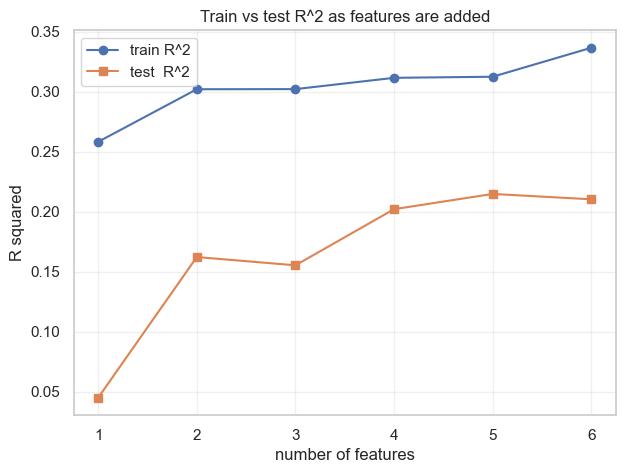

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results_df["n_features"], results_df["train_r2"], marker="o", label="train R^2")
ax.plot(results_df["n_features"], results_df["test_r2"],  marker="s", label="test  R^2")
ax.set_xlabel("number of features")
ax.set_ylabel("R squared")
ax.set_title("Train vs test R^2 as features are added")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

- The **train curve** climbs monotonically — adding features cannot hurt the in-sample fit.
- The **test curve** tells the honest story: the gap between the two is the overfitting penalty.
- On a sample this small (24 test rows) the test curve is noisy; a single resample with a different `random_state` can shift the apparent "best" feature count by one or two.

That is exactly why a robust workflow uses cross-validation rather than one split — **see Lecture 13**.

What we *can* legitimately do with this curve is read it qualitatively: most of the predictive value lives in the first 2–3 features ranked by training correlation; adding the rest gives marginal-to-negative test improvement.


## H. What comes next

- **`lec_11d`** revisits the coefficient table from section D with a critical eye: when features are correlated with each other, the *partial effect* interpretation gets slippery, and a coefficient flipping sign between the simple and multiple fit is not a bug — it is the whole point.
- **`lec_11e`** moves to **polynomial regression** and introduces **regularisation** (Ridge, Lasso). The overfitting curve we saw in section G is visually unmistakable in 1D once we add polynomial features, and the regularised fits are the principled response. `lec_11e` also revives the three-way split — this time honestly, on enough data to support it — to pick the regularisation strength α on the validation slice without touching the test set.
- **`lec_11f`** (optional, career-track) covers VIF, ElasticNet, robust regression, Bayesian regression, and quantile regression.
- **Lecture 13** replaces the single train/test split with **cross-validation**, the principled answer to the "but the curve is noisy" complaint in section G.